# Decision Tree — Full Deep Dive

In [ ]:
The Story First 📖

Imagine you're deciding whether to play cricket outside:

Is it raining?
├── YES → Don't play ❌
└── NO  → Is it too hot?
          ├── YES → Don't play ❌
          └── NO  → PLAY! ✅

This exact logic = Decision Tree!
A series of yes/no questions
until you reach a final answer!

In [ ]:
How Decision Tree Works:
ROOT NODE → first question (most important feature)
     │
     ├── BRANCH → answer path
     │
     ├── INTERNAL NODE → next question
     │
     └── LEAF NODE → final answer (prediction)

In [ ]:
Visual:
        [Age > 40?]          ← ROOT NODE
        /         \
      YES          NO
      /              \
  [Bought ✅]    [Salary > 50k?]   ← INTERNAL NODE
                  /        \
                YES          NO
                /              \
          [Bought ✅]    [Not Bought ❌]  ← LEAF NODES

# How Model Decides Which Feature to Split First?
Two methods — both important for interviews!

In [ ]:
Method 1 — Gini Impurity:



Measures how "mixed" a group is

Gini = 0   → perfectly pure
             (all Pass or all Fail)
Gini = 0.5 → perfectly mixed
             (50% Pass, 50% Fail)

Model picks feature that gives
LOWEST gini (most pure groups)!
Simple example:
Group A: [Pass, Pass, Pass, Fail]
Gini = low → mostly pure ✅

Group B: [Pass, Fail, Pass, Fail]
Gini = high → very mixed ❌

Model prefers Group A split!

In [ ]:
Method 2 — Information Gain (Entropy):


Entropy = how much disorder/chaos in data

High entropy → very mixed → bad split
Low entropy  → very pure  → good split!

Model picks feature with
HIGHEST information gain!

In [2]:

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score , confusion_matrix, classification_report

# data
data = {
    "age"       : [22,25,47,52,46,56,55,60,62,61,
                   18,28,27,29,49,55,25,58,19,40],
    "salary"    : [15,18,60,80,55,90,85,95,100,98,
                   12,20,22,25,65,88,19,92,14,45],
    "bought"    : [0,0,1,1,1,1,0,1,1,1,
                   0,0,0,0,1,1,0,1,0,1]
}


df= pd.DataFrame(data)

X= df[["age","salary"]]
y= df["bought"]


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# create model — parameters explained below!
model = DecisionTreeClassifier(
            criterion="gini", # how to measure split quality
            max_depth=3,        # how deep the tree can grow
            min_samples_split=2,# minimum samples to split a node
            min_samples_leaf=1,# minimum samples in leaf node
            random_state=42  # reproducibility
)

model.fit(X_train,y_train)
y_pred= model.predict(X_test)


print("predicted :", y_pred)
print("actual :", list(y_test))
print("accuracy :", accuracy_score(y_test,y_pred))
print("\nClassification Report :")
print(classification_report(y_test,y_pred))



_

predicted : [0 1 1 0]
actual : [0, 1, 1, 0]
accuracy : 1.0

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



''

# Parameters Explained 

In [ ]:
criterion="gini":

"gini"    → uses Gini Impurity (default, faster)
"entropy" → uses Information Gain (slower, similar results)

Which to use?
→ gini for most cases ✅
→ try both and compare!

In [ ]:
max_depth=3:

controls how deep tree can grow

max_depth=1  → only 1 question (too simple, underfit)
max_depth=3  → 3 levels of questions (balanced ✅)
max_depth=10 → 10 levels (too complex, overfit!)
max_depth=None → grows until pure (usually overfit!)

Visual:
depth=1:     [question1]
             /          \
           yes            no

depth=2:     [question1]
             /          \
        [question2]   [question3]
         /     \        /      \
       yes      no    yes       no

Rule of thumb: start with 3-5!


In [ ]:
min_samples_split=2:

minimum samples needed to split a node

min_samples_split=2  → split if 2+ samples (default)
min_samples_split=10 → only split if 10+ samples
                       (prevents overfitting!)

Higher value → simpler tree → less overfit


In [ ]:
min_samples_leaf=1:

minimum samples required in leaf node

min_samples_leaf=1  → leaf can have 1 sample (default)
min_samples_leaf=5  → leaf needs 5+ samples
                      (smoother, less overfit!)

Higher value → simpler tree → less overfit


# Visualizing the Tree

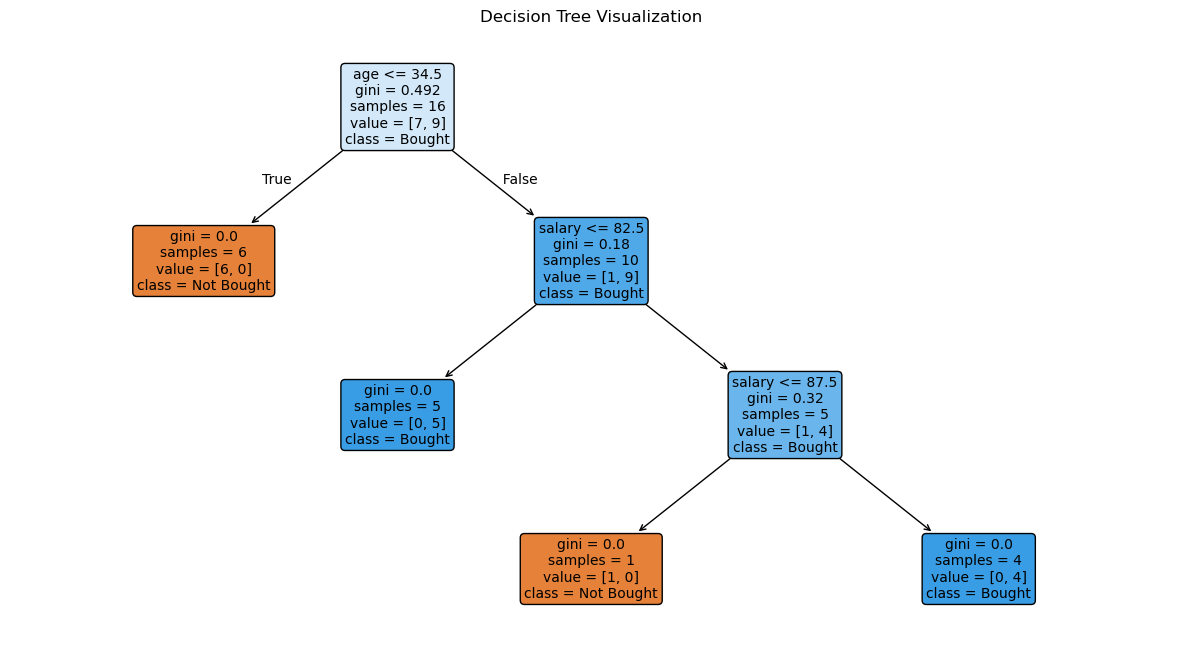

In [3]:
plt.figure(figsize=(15,8))
plot_tree(model,
                feature_names=["age","salary"],
                class_names=["Not Bought","Bought"],
                filled = True,# color the nodes
                rounded=True,# round corners
                fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

# Feature Importance — Which feature mattered most?

In [4]:
importance = pd.DataFrame({
    "feature"   : ["age", "salary"],
    "importance": model.feature_importances_
})

importance= importance.sort_values(
            "importance",ascending=False
)
print(importance)

  feature  importance
0     age    0.771429
1  salary    0.228571


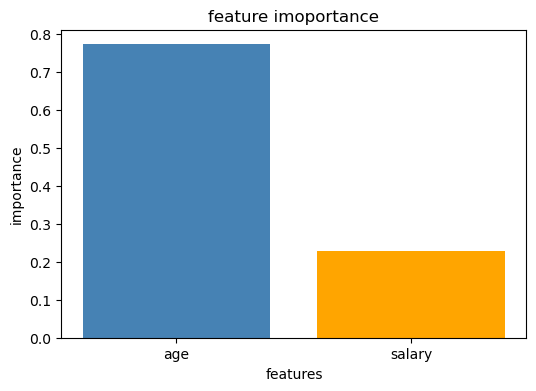

In [9]:
# plot of importance
plt.figure(figsize=(6,4))
plt.bar(importance["feature"],
        importance["importance"],
        color=["steelblue","orange"])
plt.title("feature imoportance")
plt.xlabel("features")
plt.ylabel("importance")
plt.show()




# Confusion Matrix Plot:

In [12]:
# plt.figure(figsize=(5, 4))
# plt.imshow(cm, cmap="Blues")
# plt.colorbar()
# plt.title("Confusion Matrix")
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.xticks([0,1], ["Not Bought", "Bought"])
# plt.yticks([0,1], ["Not Bought", "Bought"])
# for i in range(2):
#     for j in range(2):
#         plt.text(j, i, cm[i,j],
#                 ha="center", va="center",
#                 color="red", fontsize=20)
# plt.tight_layout()
# plt.show()


In [ ]:
Overfitting in Decision Tree — Very Important!



max_depth = None (unlimited):
→ tree memorizes every single sample
→ 100% accuracy on train data
→ terrible on test data
→ OVERFIT! ❌

max_depth = 3 (limited):
→ tree learns general patterns
→ good accuracy on both train and test
→ balanced! ✅

Always check:
train accuracy vs test accuracy

train=99%, test=99% → great! ✅
train=99%, test=60% → overfit! ❌
train=60%, test=60% → underfit! ❌

In [ ]:

Notes Summary 📝
Decision Tree:
→ works like a flowchart of yes/no questions
→ used for both classification & regression
→ very easy to visualize and explain!

Parameters:
→ criterion      = gini or entropy
→ max_depth      = controls tree size (3-5 is good)
→ min_samples_split = min samples to split
→ min_samples_leaf  = min samples in leaf

Feature Importance:
→ model.feature_importances_
→ tells which feature mattered most!

Overfitting:
→ max_depth too high = overfit
→ max_depth too low  = underfit
→ always compare train vs test accuracy!

Advantages:
→ easy to understand and visualize
→ no need to scale data!
→ works with both numerical & categorical

Disadvantages:
→ easily overfits
→ small data change = completely different tree
→ that's why Random Forest was invented!

# How to Detect Overfitting/Underfitting:

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(max_depth=3,
                                random_state=42)
model.fit(X_train, y_train)

# check BOTH train and test accuracy!
train_acc = accuracy_score(y_train,
                           model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print("Train Accuracy:", train_acc)
print("Test Accuracy :", test_acc)
print("Difference    :", train_acc - test_acc)




Reading results:
Difference < 0.05 → Good Fit ✅
Difference > 0.10 → Overfitting ❌
Both scores low   → Underfitting ❌

Train Accuracy: 1.0
Test Accuracy : 1.0
Difference    : 0.0
